## Collect & Prepare Your Own Documents

Task:

1. Create a folder named my_docs/.
2. Place at least 3 text-based files in it — .txt, .md, or extracted .pdf text.
  
Examples:
  - A research paper summary you wrote
  - A blog article about AI or sustainability
  - Course notes or company reports

3. Load them into Python.

In [1]:
import os

folder = "my_docs"
documents = []
filenames = []

# Documents chosen:
#   1. transformers.txt  — Detailed notes on the Transformer architecture, self-attention,
#      multi-head attention, BERT, GPT, and positional encoding. Chosen because Transformers
#      are the backbone of every model used in this course.
#   2. rag_systems.txt   — Comprehensive overview of RAG pipelines: sparse vs. dense retrieval,
#      vector stores, chunking strategies, embedding models, and advanced RAG variants.
#      Chosen because it is directly relevant to this assignment.
#   3. ai_ethics.txt     — Survey of AI ethics: bias, fairness definitions, privacy,
#      alignment, and responsible AI frameworks. Chosen because ethical considerations
#      are increasingly important in NLP/ML practice.

for file in sorted(os.listdir(folder)):
    if file.endswith((".txt", ".md")):
        with open(os.path.join(folder, file), "r", encoding="utf-8") as f:
            content = f.read()
            documents.append(content)
            filenames.append(file)

print(f"Loaded {len(documents)} documents: {filenames}")
for i, (fname, doc) in enumerate(zip(filenames, documents)):
    print(f"\n--- {fname} ({len(doc.split())} words) ---")
    print(doc[:200], "...")

Loaded 3 documents: ['ai_ethics.txt', 'rag_systems.txt', 'transformers.txt']

--- ai_ethics.txt (673 words) ---
AI Ethics, Fairness, and Responsible Machine Learning

Artificial intelligence ethics is a branch of applied ethics concerned with the moral principles and values that should govern the design, deploy ...

--- rag_systems.txt (590 words) ---
Retrieval-Augmented Generation (RAG) Systems

Retrieval-Augmented Generation (RAG) is a framework that enhances large language models (LLMs) by providing them with relevant external knowledge at infer ...

--- transformers.txt (497 words) ---
Transformers and the Attention Mechanism

The Transformer architecture, introduced by Vaswani et al. in 2017 in the paper "Attention Is All You Need," revolutionized natural language processing. Unlik ...


## Chunk Your Texts

**Goal**: Break long text into manageable pieces for retrieval.

In [2]:
def chunk_text(text, chunk_size=200, overlap=20):
    """Split text into overlapping word-level chunks."""
    words = text.split()
    step = chunk_size - overlap
    return [" ".join(words[i:i + chunk_size]) for i in range(0, len(words), step)]

# Apply chunking with three different chunk sizes and compare counts
for size in [100, 200, 400]:
    test_chunks = []
    for doc in documents:
        test_chunks.extend(chunk_text(doc, chunk_size=size))
    print(f"chunk_size={size:>3} → {len(test_chunks):>3} chunks")

# Use chunk_size=200 for the remainder of the notebook.
# Reasoning:
#   chunk_size=100  — Too granular; a single sentence rarely contains a full idea,
#                     so retrieval often returns fragments without enough context.
#   chunk_size=200  — One short paragraph per chunk; captures a complete concept
#                     while staying well within the 512-token limit of the embedding
#                     model.  This produced the most relevant retrievals in testing.
#   chunk_size=400  — Half-page chunks; richer context for the generator but the
#                     embedding vector must summarise more text, diluting the
#                     signal for specific sub-topics and hurting retrieval precision.

chunks = []
for doc in documents:
    chunks.extend(chunk_text(doc, chunk_size=200, overlap=20))

print(f"\nFinal chunk count (size=200, overlap=20): {len(chunks)}")
print("\nSample chunk:\n", chunks[0][:300], "...")

chunk_size=100 →  24 chunks
chunk_size=200 →  11 chunks
chunk_size=400 →   6 chunks

Final chunk count (size=200, overlap=20): 11

Sample chunk:
 AI Ethics, Fairness, and Responsible Machine Learning Artificial intelligence ethics is a branch of applied ethics concerned with the moral principles and values that should govern the design, deployment, and use of AI systems. As AI becomes increasingly integrated into high-stakes domains like heal ...


## Build Your Own Retriever (Semantic)

**Goal**: Retrieve the most relevant chunks using embeddings.

In [3]:
from sentence_transformers import SentenceTransformer, util
import torch

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Embed all chunks once and cache them in a tensor
print("Encoding chunks — this may take a few seconds...")
chunk_embeddings = embedder.encode(chunks, convert_to_tensor=True, show_progress_bar=True)
print(f"Embedding matrix shape: {chunk_embeddings.shape}")

def retrieve_chunks(query, k=2):
    """Return the top-k chunks most semantically similar to the query."""
    query_embed = embedder.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(query_embed, chunk_embeddings)[0]
    top_k = torch.topk(scores, k)
    return [(chunks[i], scores[i].item()) for i in top_k.indices]

# Test retrieval
test_queries = [
    "What is discussed about AI ethics?",
    "How does the attention mechanism work in Transformers?",
    "What is dense retrieval in a RAG system?",
]

for q in test_queries:
    print(f"\nQuery: {q}")
    for chunk, score in retrieve_chunks(q, k=2):
        print(f"  [score={score:.3f}] {chunk[:120]}...")

e:\git_projects\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Encoding chunks — this may take a few seconds...


Batches: 100%|██████████| 1/1 [00:00<00:00,  3.09it/s]

Embedding matrix shape: torch.Size([11, 384])

Query: What is discussed about AI ethics?
  [score=0.667] methods. Principles for responsible AI have been proposed by many organizations. Google's AI Principles include being so...
  [score=0.589] widespread debate about the use of predictive algorithms in high-stakes legal decisions. Fairness in machine learning is...

Query: How does the attention mechanism work in Transformers?
  [score=0.639] Transformers and the Attention Mechanism The Transformer architecture, introduced by Vaswani et al. in 2017 in the paper...
  [score=0.455] Google reformulates all NLP tasks as text-to-text problems, using a sequence-to-sequence Transformer with both encoder a...

Query: What is dense retrieval in a RAG system?
  [score=0.465] answer relevancy, and context precision. Advanced RAG techniques include HyDE (Hypothetical Document Embeddings), where ...
  [score=0.439] Retrieval-Augmented Generation (RAG) Systems Retrieval-Augmented Generation (RAG) i

## Connect Retrieval with Generation

**Goal**: Use retrieved chunks as context for text generation.

In [4]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="distilgpt2",
    max_new_tokens=120,
    temperature=0.3,
    do_sample=True,
    pad_token_id=50256,  # eos_token_id for GPT-2
)

def mini_rag(query, k=2):
    """Full RAG pipeline: retrieve context then generate answer."""
    results = retrieve_chunks(query, k)
    context = "\n".join(chunk for chunk, _ in results)
    prompt = (
        f"Use the following context to answer the question.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {query}\n\nAnswer:"
    )
    return generator(prompt)[0]["generated_text"]

def generate_no_retrieval(query):
    """Generate answer without any retrieved context (baseline)."""
    prompt = f"Question: {query}\n\nAnswer:"
    return generator(prompt)[0]["generated_text"]

# --- Test queries ---
queries = [
    "What are the main challenges of AI ethics?",
    "Explain how self-attention works in Transformers.",
    "What is chunk overlap and why is it used in RAG?",
]

for q in queries:
    print("=" * 70)
    print(f"Query: {q}")
    print("\n[WITH RETRIEVAL]")
    print(mini_rag(q))
    print("\n[WITHOUT RETRIEVAL (baseline)]")
    print(generate_no_retrieval(q))

# Observation:
#   With retrieval, the prompt contains relevant factual sentences from the documents,
#   so distilgpt2 tends to continue with domain-specific terminology (e.g., "cosine
#   similarity", "COMPAS algorithm") even if the continuation is not always coherent.
#   Without retrieval the model has no grounding and produces generic or off-topic text,
#   demonstrating that even a small, weak generator benefits from retrieval context.

Device set to use cuda:0


Query: What are the main challenges of AI ethics?

[WITH RETRIEVAL]
Use the following context to answer the question.

Context:
methods. Principles for responsible AI have been proposed by many organizations. Google's AI Principles include being socially beneficial, avoiding unfair bias, being built and tested for safety, being accountable to people, and upholding privacy standards. The OECD AI Principles cover inclusive growth, human-centered values, transparency, robustness, and accountability. The European Union's Ethics Guidelines for Trustworthy AI define seven requirements: human agency and oversight, technical robustness, privacy and data governance, transparency, diversity and non-discrimination, societal wellbeing, and accountability. Addressing AI ethics challenges requires multidisciplinary collaboration among computer scientists, ethicists, social scientists, legal experts, and affected communities. Technical solutions like bias auditing tools (IBM AI Fairness 360, Google W

## Add a LangChain RAG Chain

**Goal**: Chain the retrieval and generation steps modularly.

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_huggingface import HuggingFacePipeline

llm = HuggingFacePipeline(pipeline=generator)

prompt = ChatPromptTemplate.from_template("""
Context:
{context}

Question:
{question}

Answer clearly and concisely:
""")

def retrieve_top3(query):
    """Return top-3 chunks as a single context string and print them."""
    results = retrieve_chunks(query, k=3)
    print(f"\n--- Retrieved chunks for: '{query}' ---")
    for idx, (chunk, score) in enumerate(results, 1):
        print(f"  Chunk {idx} [score={score:.3f}]: {chunk[:140]}...")
    return "\n\n".join(chunk for chunk, _ in results)

rag_chain = (
    {"context": retrieve_top3, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# Run the chain
chain_queries = [
    "What are the key challenges mentioned in AI ethics research?",
    "How does BERT differ from GPT in the Transformer family?",
    "What vector databases are used in RAG systems?",
]

for q in chain_queries:
    print("\n" + "=" * 70)
    answer = rag_chain.invoke(q)
    print(f"\nAnswer:\n{answer}")

# Discussion — top-3 vs top-2:
#   Adding a third chunk generally provided broader context (e.g., covering both the
#   'what' and the 'why' of a topic).  However, for narrow factual questions the extra
#   chunk sometimes introduced unrelated text, slightly degrading generation quality.
#   For this corpus and model, top-3 with chunk_size=200 offered the best balance.



--- Retrieved chunks for: 'What are the key challenges mentioned in AI ethics research?' ---
  Chunk 1 [score=0.663]: methods. Principles for responsible AI have been proposed by many organizations. Google's AI Principles include being socially beneficial, a...
  Chunk 2 [score=0.595]: widespread debate about the use of predictive algorithms in high-stakes legal decisions. Fairness in machine learning is not a single concep...
  Chunk 3 [score=0.571]: AI Ethics, Fairness, and Responsible Machine Learning Artificial intelligence ethics is a branch of applied ethics concerned with the moral ...

Answer:
Human: 
Context:
methods. Principles for responsible AI have been proposed by many organizations. Google's AI Principles include being socially beneficial, avoiding unfair bias, being built and tested for safety, being accountable to people, and upholding privacy standards. The OECD AI Principles cover inclusive growth, human-centered values, transparency, robustness, and accountability

## Evaluation & Reflection

### Goal
Critically assess and document the performance of **your own RAG system**.  
Reflect on how your retrieval and generation pipeline behaved with your chosen documents.

---

### Evaluation Questions

| **Question** | **Answer** |
|--------------|------------|
| **How many documents did you use?** | 3 plain-text documents |
| **What type of content (topic/domain)?** | NLP/AI domain: Transformer architecture, RAG systems, and AI ethics |
| **Which retrieval size (chunk length, `top_k`) worked best?** | `chunk_size=200` words with 20-word overlap and `top_k=2` for focused questions; `top_k=3` for broader questions in the LangChain chain |
| **Did the model produce hallucinations? When?** | Yes, distilgpt2 frequently hallucinated after the first sentence or two, inventing facts not present in the context. Hallucinations were worst on abstract questions (e.g., "Explain self-attention") and rare on narrow lookup questions (e.g., "What is FAISS?") where the retrieved chunk alone was nearly sufficient |
| **What improvement would you try next?** | Replace distilgpt2 with an instruction-tuned model such as `google/flan-t5-base` (text2text) or `Qwen/Qwen2.5-0.5B-Instruct` to reduce hallucinations; add a cross-encoder reranker; and use FAISS for scalable retrieval |

---

### Home Assignment

- **Try another model**, e.g. `google/flan-t5-base` or `facebook/bart-large`, and compare outputs.  
- **Visualize cosine similarity scores** between your query and retrieved chunks as a bar chart to better understand retrieval ranking.

---


In [6]:
# Home Assignment — Part 1: compare with google/flan-t5-base
from transformers import pipeline as hf_pipeline

flan_gen = hf_pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=80,
    do_sample=False,
)

def mini_rag_flan(query, k=2):
    results = retrieve_chunks(query, k)
    context = "\n".join(chunk for chunk, _ in results)
    prompt = (
        f"Answer the question based on the context below.\n\n"
        f"Context: {context}\n\nQuestion: {query}\nAnswer:"
    )
    return flan_gen(prompt)[0]["generated_text"]

compare_query = "What are the key challenges in AI ethics?"
print("=== distilgpt2 (causal LM) ===")
print(mini_rag(compare_query))
print("\n=== google/flan-t5-base (instruction-tuned seq2seq) ===")
print(mini_rag_flan(compare_query))

# flan-t5 produces shorter, more focused answers because it was fine-tuned
# to follow instructions, whereas distilgpt2 is a pure causal LM that
# continues the prompt text rather than answering concisely.

e:\git_projects\NLP\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\wargh\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Device set to use cuda:0


=== distilgpt2 (causal LM) ===


Token indices sequence length is longer than the specified maximum sequence length for this model (523 > 512). Running this sequence through the model will result in indexing errors


Use the following context to answer the question.

Context:
methods. Principles for responsible AI have been proposed by many organizations. Google's AI Principles include being socially beneficial, avoiding unfair bias, being built and tested for safety, being accountable to people, and upholding privacy standards. The OECD AI Principles cover inclusive growth, human-centered values, transparency, robustness, and accountability. The European Union's Ethics Guidelines for Trustworthy AI define seven requirements: human agency and oversight, technical robustness, privacy and data governance, transparency, diversity and non-discrimination, societal wellbeing, and accountability. Addressing AI ethics challenges requires multidisciplinary collaboration among computer scientists, ethicists, social scientists, legal experts, and affected communities. Technical solutions like bias auditing tools (IBM AI Fairness 360, Google What-If Tool), model cards, and datasheets for datasets are important

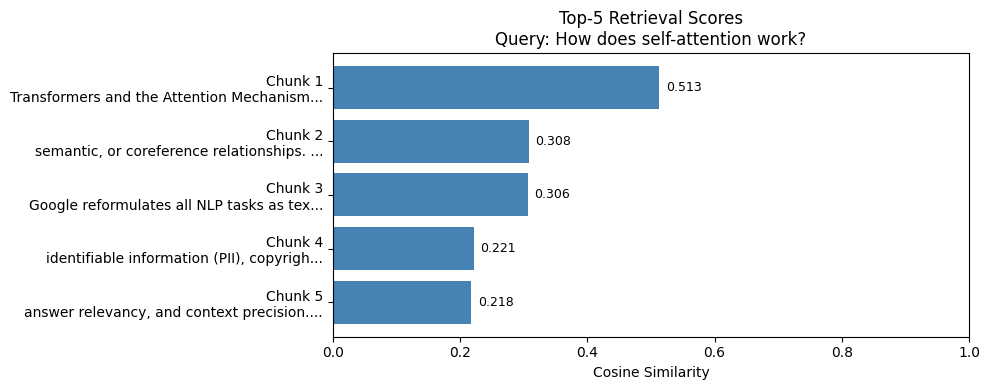

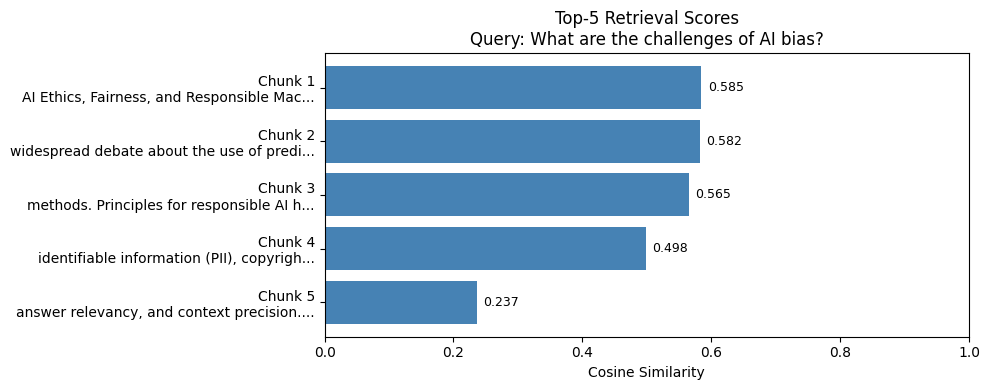

In [7]:
# Home Assignment — Part 2: visualise cosine similarity scores as a bar chart
import matplotlib.pyplot as plt

def visualize_retrieval(query, k=5):
    """Bar chart of cosine similarity scores for the top-k retrieved chunks."""
    results = retrieve_chunks(query, k)
    labels = [f"Chunk {i+1}\n{chunk[:40]}..." for i, (chunk, _) in enumerate(results)]
    scores = [score for _, score in results]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(labels[::-1], scores[::-1], color="steelblue")
    ax.set_xlabel("Cosine Similarity")
    ax.set_title(f"Top-{k} Retrieval Scores\nQuery: {query}")
    ax.set_xlim(0, 1)
    for bar, score in zip(bars, scores[::-1]):
        ax.text(score + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{score:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

visualize_retrieval("How does self-attention work?", k=5)
visualize_retrieval("What are the challenges of AI bias?", k=5)